In [3]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parents[1]))

import joblib
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
)
from sklearn.model_selection import train_test_split

from src.features.preprocessing import split_feature_types
from src.models.mlp import ChurnMLP
from src.training.train import load_and_prepare_data
from src.training.train_mlp import split_train_val_test
from src.utils.config import (
    DOCS_DIR,
    MLP_DROPOUT_RATES,
    MLP_HIDDEN_DIMS,
    MLP_VAL_SIZE,
    RANDOM_STATE,
    TEST_SIZE,
    get_models_dir,
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [ ]:
# carrega a tabela gerada pelo script
comparison_df = pd.read_csv(DOCS_DIR / 'model_comparison.csv', index_col=0)
comparison_df.columns = [c.replace('holdout_', '') for c in comparison_df.columns]
comparison_df.round(4)

,roc_auc,pr_auc,f1,recall,precision,accuracy
dummy,0.5000,0.2654,0.0000,0.0000,0.0000,0.7346
logistic_regression,0.8431,0.6385,0.6157,0.7861,0.5060,0.7395
decision_tree,0.7939,0.5659,0.5962,0.7914,0.4782,0.7154
mlp_pytorch,0.8470,0.6318,0.6197,0.7857,0.5116,0.7446


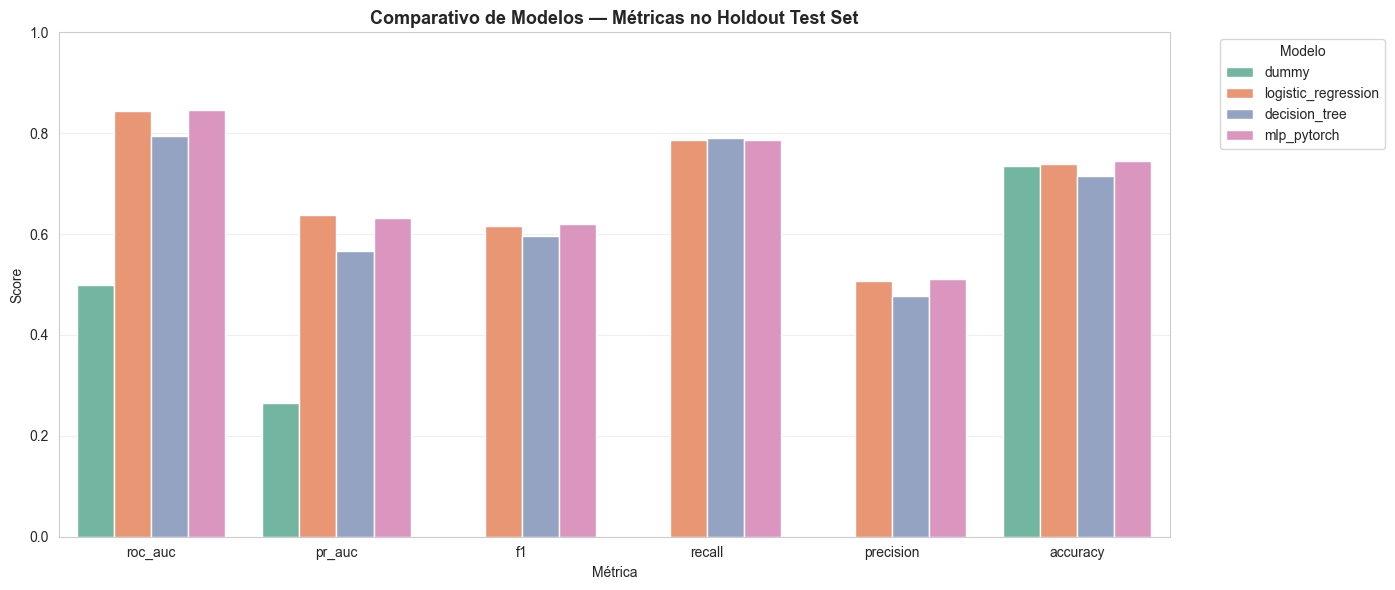

In [5]:
# grafico comparativo

metrics_to_plot = ['roc_auc', 'pr_auc', 'f1', 'recall', 'precision', 'accuracy']
df_plot = comparison_df[metrics_to_plot].reset_index().rename(columns={'index': 'model'})
df_melt = df_plot.melt(id_vars='model', var_name='metric', value_name='score')

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=df_melt, x='metric', y='score', hue='model', ax=ax, palette='Set2')
ax.set_title('Comparativo de Modelos — Métricas no Holdout Test Set', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xlabel('Métrica')
ax.set_ylim(0, 1.0)
ax.legend(title='Modelo', loc='upper right', bbox_to_anchor=(1.2, 1))
ax.yaxis.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(DOCS_DIR / 'comparison_bars.png', dpi=150, bbox_inches='tight')
plt.show()

Gera as curvas ROC

In [6]:
# carrega dados
X, y = load_and_prepare_data()

# divide 80/20
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

# Split 70/15/15 (usado pelo MLP)
_, _, X_test_mlp, _, _, y_test_mlp = split_train_val_test(
    X, y, test_size=TEST_SIZE * 0.75, val_size=MLP_VAL_SIZE,
    random_state=RANDOM_STATE,
)

print(f'Test set baselines: {X_test_base.shape}')
print(f'Test set MLP: {X_test_mlp.shape}')

2026-04-21 12:12:02,528 - INFO - Carregando dataset de C:\Users\gfrei\Documents\1. FIAP\3. FASE1\9. TECH_CHALLENGE\tech-challenge-fase01\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv
2026-04-21 12:12:02,552 - INFO - Dados carregados com sucesso: 7043 linhas, 21 colunas
2026-04-21 12:12:02,553 - INFO - Limpando dados (sem cálculo de estatísticas globais)...
2026-04-21 12:12:02,559 - INFO - Coluna 'TotalCharges' convertida para numérico; 11 valores coagidos para NaN.
2026-04-21 12:12:02,568 - INFO - Coluna 'TotalCharges': 11 valores nulos (0.16%) -- serão tratados no pipeline sklearn.
2026-04-21 12:12:02,578 - INFO - Nenhum registro duplicado encontrado.
2026-04-21 12:12:02,582 - INFO - Limpeza concluída: 7043 linhas, 21 colunas, 11 valores nulos restantes (tratados no pipeline)
2026-04-21 12:12:02,583 - INFO - Aplicando feature engineering...
2026-04-21 12:12:02,584 - INFO - Colunas 'Partner' e 'Dependents' encontradas. Criando 'FamilyStatus'.
2026-04-21 12:12:02,616 - INFO - Variável '

Test set baselines: (1409, 26)
Test set MLP: (1057, 26)


In [7]:
# gera probabilidades dos baselines
baseline_models = {
    'Logistic Regression': joblib.load(get_models_dir() / 'logistic_regression.pkl'),
    'Decision Tree': joblib.load(get_models_dir() / 'decision_tree.pkl'),
}

probas = {}
y_true_by_model = {}

for name, pipeline in baseline_models.items():
    probas[name] = pipeline.predict_proba(X_test_base)[:, 1]
    y_true_by_model[name] = y_test_base.values

# gera probs do MLP
preprocessor = joblib.load(get_models_dir() / 'mlp_preprocessor.pkl')
X_test_mlp_prep = preprocessor.transform(X_test_mlp)
n_features = X_test_mlp_prep.shape[1]

mlp_model = ChurnMLP(n_features=n_features, hidden_dims=MLP_HIDDEN_DIMS, dropout_rates=MLP_DROPOUT_RATES)
mlp_model.load_state_dict(torch.load(get_models_dir() / 'mlp.pt', weights_only=True))
mlp_model.eval()

with torch.no_grad():
    X_tensor = torch.from_numpy(X_test_mlp_prep.astype(np.float32))
    logits = mlp_model(X_tensor)
    probas['MLP (PyTorch)'] = torch.sigmoid(logits).numpy().ravel()
    y_true_by_model['MLP (PyTorch)'] = y_test_mlp.values

print('Probabilidades geradas para:', list(probas.keys()))

Probabilidades geradas para: ['Logistic Regression', 'Decision Tree', 'MLP (PyTorch)']


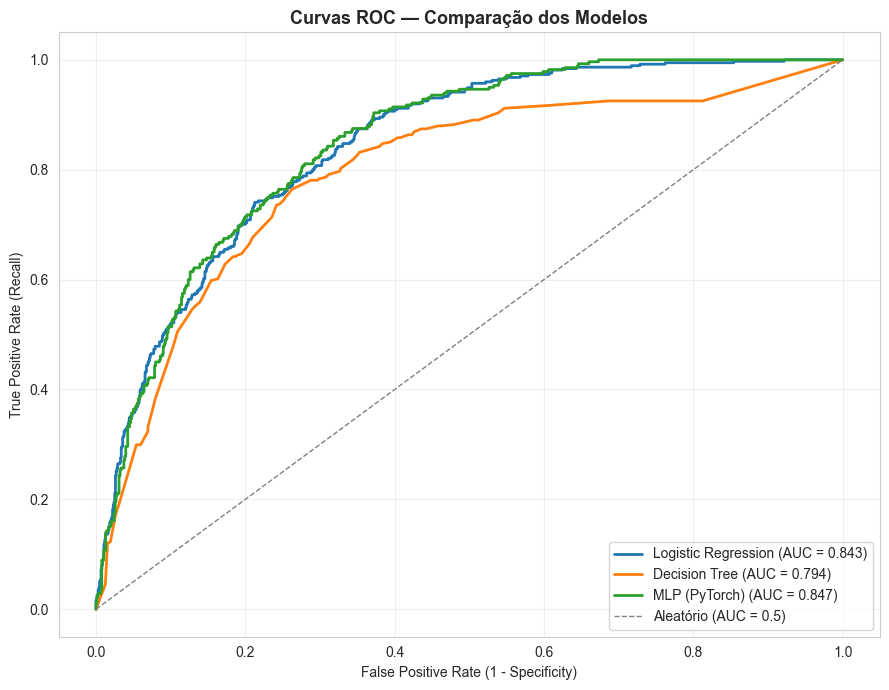

In [8]:
# plot das curvas roc
fig, ax = plt.subplots(figsize=(9, 7))

colors = {'Logistic Regression': '#1f77b4', 'Decision Tree': '#ff7f0e', 'MLP (PyTorch)': '#2ca02c'}

for model_name, proba in probas.items():
    y_true = y_true_by_model[model_name]
    fpr, tpr, _ = roc_curve(y_true, proba)
    auc = comparison_df.loc[model_name.lower().replace(' ', '_').replace('_(pytorch)', '_pytorch'), 'roc_auc']
    # Fallback por nome legível
    key_map = {'Logistic Regression': 'logistic_regression', 'Decision Tree': 'decision_tree', 'MLP (PyTorch)': 'mlp_pytorch'}
    auc = comparison_df.loc[key_map[model_name], 'roc_auc']
    ax.plot(fpr, tpr, linewidth=2, label=f'{model_name} (AUC = {auc:.3f})', color=colors.get(model_name))

ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1, label='Aleatório (AUC = 0.5)')
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('Curvas ROC — Comparação dos Modelos', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(DOCS_DIR / 'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

Curvas da PR-AUC

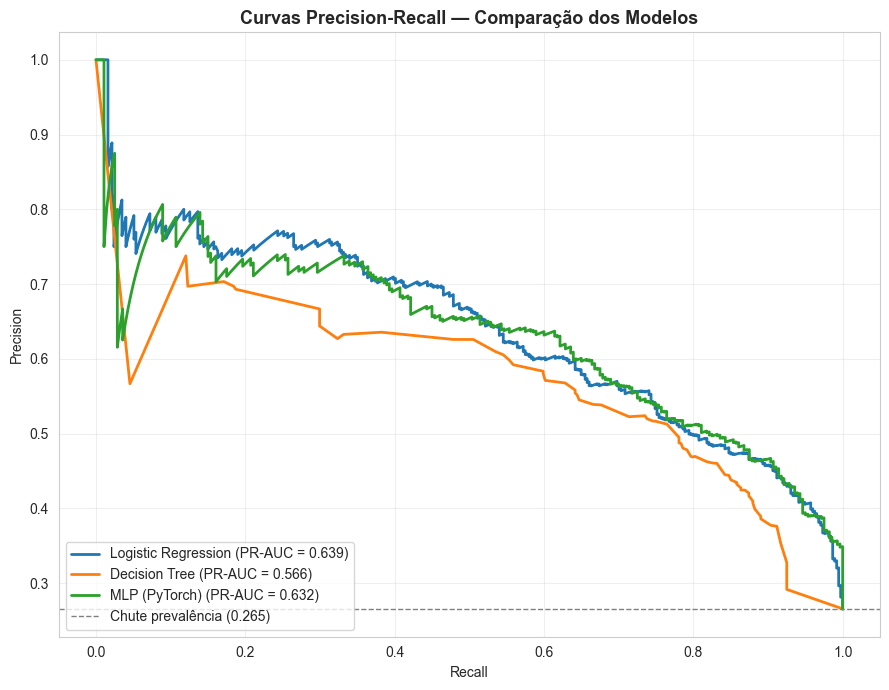

In [9]:
fig, ax = plt.subplots(figsize=(9, 7))

for model_name, proba in probas.items():
    y_true = y_true_by_model[model_name]
    precision, recall, _ = precision_recall_curve(y_true, proba)
    key_map = {'Logistic Regression': 'logistic_regression', 'Decision Tree': 'decision_tree', 'MLP (PyTorch)': 'mlp_pytorch'}
    pr_auc = comparison_df.loc[key_map[model_name], 'pr_auc']
    ax.plot(recall, precision, linewidth=2, label=f'{model_name} (PR-AUC = {pr_auc:.3f})', color=colors.get(model_name))

# Linha baseline: prevalência da classe positiva
prevalence = y_test_base.mean()
ax.axhline(y=prevalence, linestyle='--', color='gray', linewidth=1, label=f'Chute prevalência ({prevalence:.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Curvas Precision-Recall — Comparação dos Modelos', fontsize=13, fontweight='bold')
ax.legend(loc='lower left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(DOCS_DIR / 'pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

Matriz de Confusão

In [10]:
cost_df = pd.read_csv(DOCS_DIR / 'cost_analysis.csv')
cost_df.head()

,threshold,tn,fp,fn,tp,n_flagged,recall,precision,cost_fn_total,cost_fp_total,total_cost
0,0.05,116,661,0,280,941,1.0,0.297556,0.0,33050.0,33050.0
1,0.06,138,639,0,280,919,1.0,0.304679,0.0,31950.0,31950.0
2,0.07,168,609,0,280,889,1.0,0.314961,0.0,30450.0,30450.0
3,0.08,189,588,0,280,868,1.0,0.322581,0.0,29400.0,29400.0
4,0.09,201,576,0,280,856,1.0,0.327103,0.0,28800.0,28800.0


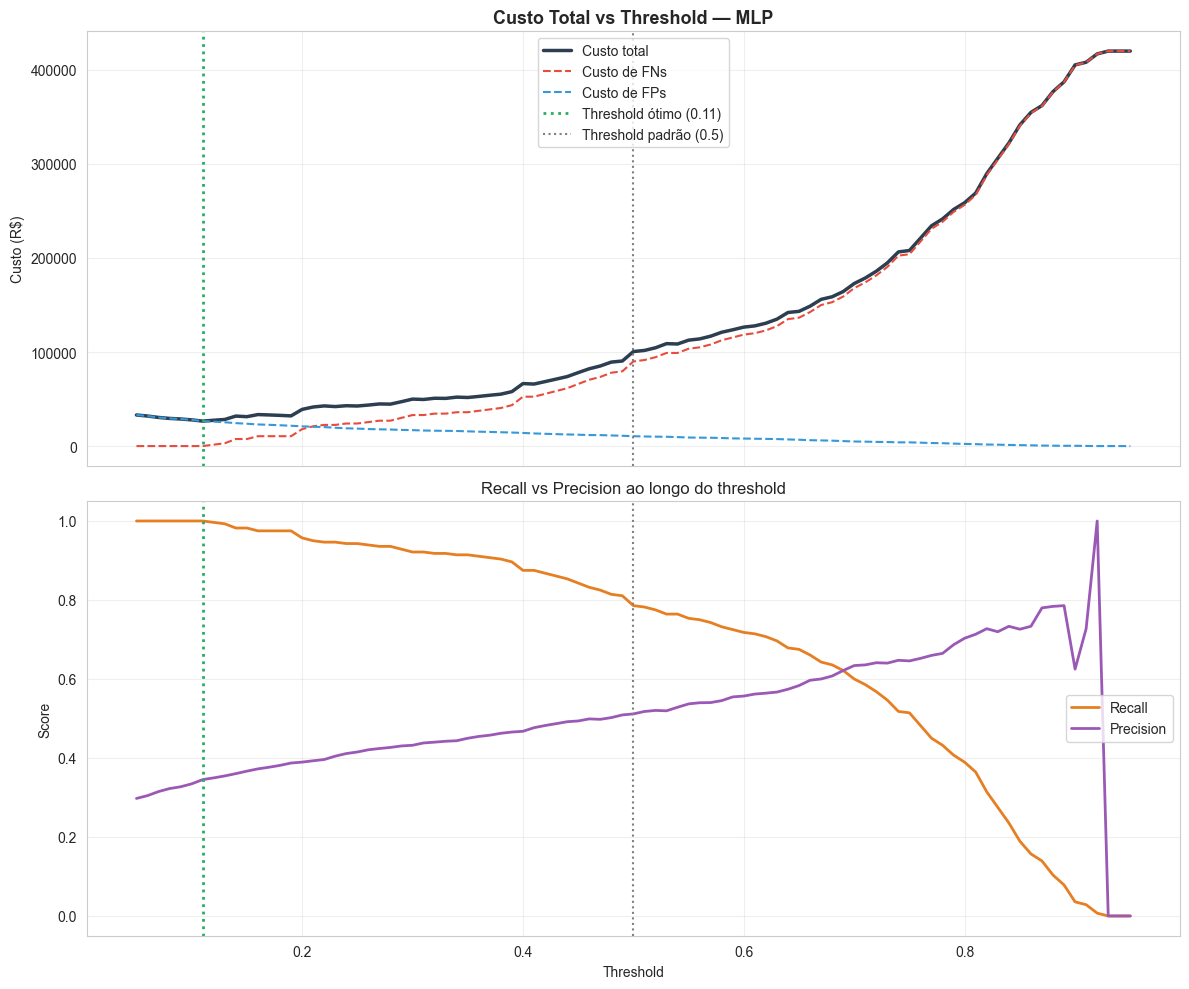


Threshold ótimo: 0.11
  FP=531, FN=0
  Custo total: R$ 26,550.00

Threshold padrão (0.5):
  FP=210, FN=60
  Custo total: R$ 100,500.00

Economia ao usar threshold ótimo: R$ 73,950.00


In [ ]:
optimal = cost_df.loc[cost_df['total_cost'].idxmin()]
default = cost_df.iloc[(cost_df['threshold'] - 0.5).abs().argmin()]

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# P1: custo total + componentes
ax = axes[0]
ax.plot(cost_df['threshold'], cost_df['total_cost'], linewidth=2.5, color='#2c3e50', label='Custo total')
ax.plot(cost_df['threshold'], cost_df['cost_fn_total'], linewidth=1.5, color='#e74c3c', linestyle='--', label='Custo de FNs')
ax.plot(cost_df['threshold'], cost_df['cost_fp_total'], linewidth=1.5, color='#3498db', linestyle='--', label='Custo de FPs')

ax.axvline(optimal['threshold'], color='#27ae60', linestyle=':', linewidth=2, label=f"Threshold ótimo ({optimal['threshold']:.2f})")
ax.axvline(0.5, color='gray', linestyle=':', linewidth=1.5, label='Threshold padrão (0.5)')

ax.set_ylabel('Custo (R$)')
ax.set_title('Custo Total vs Threshold — MLP', fontsize=13, fontweight='bold')
ax.legend(loc='upper center')
ax.grid(alpha=0.3)

# P2: recall e precision
ax = axes[1]
ax.plot(cost_df['threshold'], cost_df['recall'], linewidth=2, color='#e67e22', label='Recall')
ax.plot(cost_df['threshold'], cost_df['precision'], linewidth=2, color='#9b59b6', label='Precision')
ax.axvline(optimal['threshold'], color='#27ae60', linestyle=':', linewidth=2)
ax.axvline(0.5, color='gray', linestyle=':', linewidth=1.5)

ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Recall vs Precision ao longo do threshold', fontsize=12)
ax.legend(loc='center right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(DOCS_DIR / 'cost_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nThreshold ótimo: {optimal['threshold']:.2f}")
print(f"  FP={int(optimal['fp'])}, FN={int(optimal['fn'])}")
print(f"  Custo total: R$ {optimal['total_cost']:,.2f}")
print(f"\nThreshold padrão (0.5):")
print(f"  FP={int(default['fp'])}, FN={int(default['fn'])}")
print(f"  Custo total: R$ {default['total_cost']:,.2f}")
print(f"\nEconomia ao usar threshold ótimo: R$ {default['total_cost'] - optimal['total_cost']:,.2f}")

In [12]:
# distribuicao das probabilidades
mlp_probas = probas['MLP (PyTorch)']
mlp_y_true = y_true_by_model['MLP (PyTorch)']

probas_nao_churn = mlp_probas[mlp_y_true == 0]
probas_churn = mlp_probas[mlp_y_true == 1]

print(f"Não-churners: {len(probas_nao_churn)} clientes, prob média = {probas_nao_churn.mean():.3f}")
print(f"Churners:     {len(probas_churn)} clientes, prob média = {probas_churn.mean():.3f}")

Não-churners: 777 clientes, prob média = 0.321
Churners:     280 clientes, prob média = 0.681


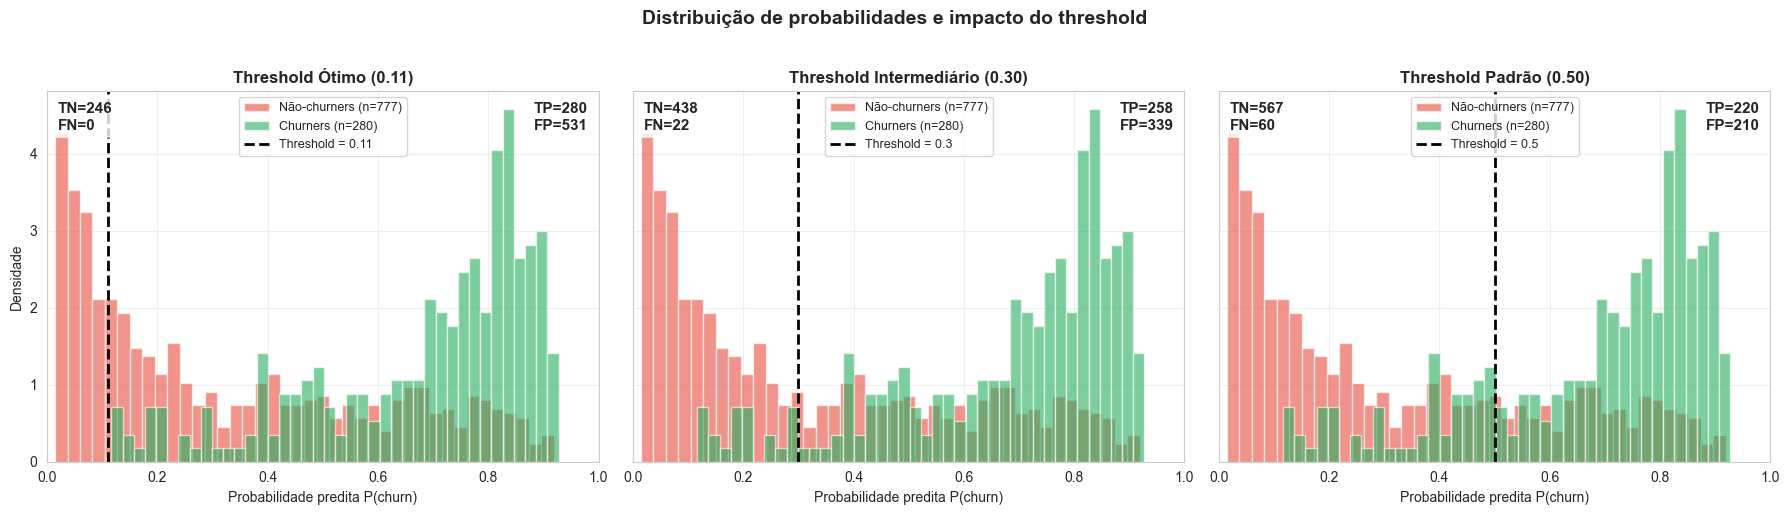

In [ ]:
thresholds_compare = [0.11, 0.30, 0.50]
threshold_labels = ['Ótimo (0.11)', 'Intermediário (0.30)', 'Padrão (0.50)']

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, t, label in zip(axes, thresholds_compare, threshold_labels):
    ax.hist(probas_nao_churn, bins=40, alpha=0.6, color='#e74c3c',
            label=f'Não-churners (n={len(probas_nao_churn)})', density=True)
    ax.hist(probas_churn, bins=40, alpha=0.6, color='#27ae60',
            label=f'Churners (n={len(probas_churn)})', density=True)
    
    ax.axvline(t, color='black', linestyle='--', linewidth=2, label=f'Threshold = {t}')
    
    tp = int((probas_churn > t).sum())
    fn = int((probas_churn <= t).sum())
    fp = int((probas_nao_churn > t).sum())
    tn = int((probas_nao_churn <= t).sum())
    
    ax.text(0.02, 0.97, f'TN={tn}\nFN={fn}',
            transform=ax.transAxes, fontsize=11, fontweight='bold',
            verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.text(0.98, 0.97, f'TP={tp}\nFP={fp}',
            transform=ax.transAxes, fontsize=11, fontweight='bold',
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_title(f'Threshold {label}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Probabilidade predita P(churn)')
    if ax is axes[0]:
        ax.set_ylabel('Densidade')
    ax.legend(loc='upper center', fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 1)

plt.suptitle('Distribuição de probabilidades e impacto do threshold',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(DOCS_DIR / 'probability_distributions.png', dpi=150, bbox_inches='tight')
plt.show()